In [19]:
import numpy as np
import rasterio
from pysheds.grid import Grid

# Step 1: Initialize Grid and Load DEM
def load_and_preprocess_dem(dem_file):
    grid = Grid.from_raster(dem_file)
    dem = grid.read_raster(dem_file)
    # Filling pits and resolving flats is essential for the fdir logic below
    pit_filled = grid.fill_pits(dem)
    flooded_dem = grid.resolve_flats(pit_filled)
    return grid, flooded_dem

# Step 2 & 3: Flow Direction and Accumulation
def calculate_hydrology(grid, dem):
    """
    Calculates flow direction and accumulation using optimized pysheds methods.
    """
    # Calculate flow direction (D8 algorithm)
    # pysheds uses ESRI convention by default (1, 2, 4, 8, 16, 32, 64, 128)
    fdir = grid.flowdir(dem)
    
    # Calculate flow accumulation
    acc = grid.accumulation(fdir)
    
    return fdir, acc

# Step 4: Calculate HAND
def calculate_hand_model(grid, fdir, dem, acc, threshold=500):
    """
    Using the verified 'compute_hand' method from your Grid object.
    """
    # 1. Create the stream mask (Boolean)
    is_drainage = (acc > threshold)
    
    # 2. Call the built-in compute_hand method
    # For D8 flow direction, it internally uses _d8_compute_hand
    hand = grid.compute_hand(fdir, dem, is_drainage)
    
    return hand

# Step 5: Saving the Raster
def save_raster(output_file, data, grid):
    """
    Save the HAND raster using the grid's metadata.
    """
    grid.to_raster(data, output_file)

# Step 6: Generate Rating Curve
def generate_rating_curve(hand_data):
    """
    Simplified rating curve based on the HAND distribution.
    """
    # We use HAND values to understand potential flood depths
    thresholds = np.nanpercentile(hand_data, [10, 50, 90])
    rating_curve = [(round(t, 2), round(d, 2)) for t, d in zip(thresholds, [0.1, 0.5, 1.0])]
    return rating_curve

In [33]:
# --- Main Execution ---
# --- Execution ---
dem_path = 'dem.tiff'
output_path = 'hand_model.tif'

try:
    print("Loading and preprocessing...")
    grid, dem = load_and_preprocess_dem(dem_path)

    print("Calculating Flow Direction and Accumulation...")
    fdir = grid.flowdir(dem)
    acc = grid.accumulation(fdir)

    print("Generating HAND model with compute_hand...")
    # Adjust threshold as needed for the Piura Basin scale
    hand = calculate_hand_model(grid, fdir, dem, acc, threshold=10)

    print(f"Saving to {output_path}...")
    grid.to_raster(hand, output_path)
    
    print("Success! HAND model created.")

except Exception as e:
    print(f"An error occurred: {e}")

Loading and preprocessing...
Calculating Flow Direction and Accumulation...
Generating HAND model with compute_hand...
Saving to hand_model.tif...
Success! HAND model created.


In [34]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_hydrology_results(dem, fdir, acc, hand):
    """
    Plots a 2x2 comparison of the Hydrological processing steps.
    """
    fig, ax = plt.subplots(2, 2, figsize=(14, 12))
    fig.subplots_adjust(hspace=0.3, wspace=0.2)

    # 1. Preprocessed DEM
    im1 = ax[0, 0].imshow(dem, cmap='terrain')
    ax[0, 0].set_title('Preprocessed DEM (Elevation)')
    fig.colorbar(im1, ax=ax[0, 0], label='Meters')

    # 2. Flow Direction
    # Using 'twilight' or 'hsv' is good for directional data (0-255)
    im2 = ax[0, 1].imshow(fdir, cmap='viridis')
    ax[0, 1].set_title('Flow Direction (D8)')
    fig.colorbar(im2, ax=ax[0, 1], label='ESRI Direction Code')

    # 3. Flow Accumulation (Log Scale)
    # Most cells have 0-10 acc, while rivers have 1,000,000. LogNorm is key.
    im3 = ax[1, 0].imshow(acc + 1, cmap='Blues', norm=LogNorm())
    ax[1, 0].set_title('Flow Accumulation (Log Scale)')
    fig.colorbar(im3, ax=ax[1, 0], label='Upstream Cells')

    # 4. HAND Model
    # Using 'magma' or 'terrain_r' highlights low-lying floodplains
    im4 = ax[1, 1].imshow(hand, cmap='magma_r')
    ax[1, 1].set_title('HAND Model (Height Above Nearest Drainage)')
    fig.colorbar(im4, ax=ax[1, 1], label='Relative Elevation (m)')

    plt.suptitle('Piura River Basin - Hydrological Analysis', fontsize=16)
    plt.show()

# --- Call this at the end of your main execution ---
# plot_hydrology_results(dem, fdir, acc, hand)

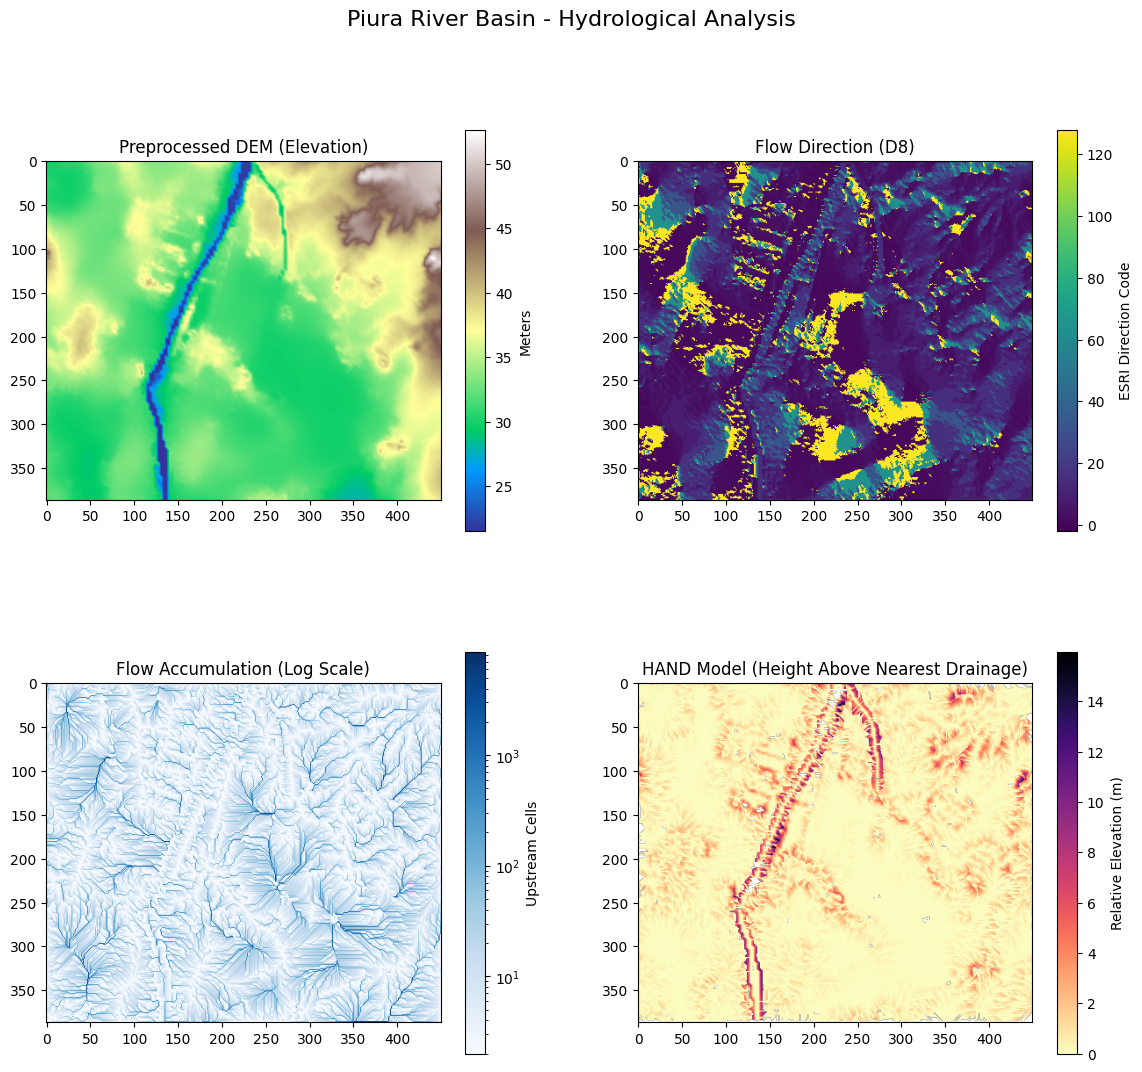

In [35]:
plot_hydrology_results(dem, fdir, acc, hand)